# Sprint v5.5 — Foundation Repair (before / after)

A corrective sprint. An audit before Tier 2 found that **three different
residuals travelled under the name `rv_hy_ig`**, and the one published to
`features.parquet` and the dashboard was a *whitened* (overfit) residual
that the v5 backtest itself refused to trade.

This notebook shows the repair, before vs after, in four steps:

1. **The residual** — whitened Kalman (published) vs OLS (traded).
2. **The selector** — why ADF picked the wrong one and how the
   tradeability band fixes it.
3. **The dashboard signal** — what the Today View was actually showing.
4. **Strategy A** — bit-identical pre/post repair (the winner was always
   clean).

"Before" is read from the `data/processed/_pre_v5_5/` backup; "after" is
the regenerated artifact.


In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
_here = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_here, 'pyproject.toml')) and _here != '/':
    _here = os.path.dirname(_here)
os.chdir(_here)
sys.path.insert(0, _here)
sys.path.insert(0, os.path.join(_here, 'python', 'credit'))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycredit
plt.rcParams.update({'figure.figsize': (12, 4.2), 'figure.dpi': 110})
PLOTS = Path('sprints/v5.5/plots'); PLOTS.mkdir(parents=True, exist_ok=True)

before = pd.read_parquet('data/processed/_pre_v5_5/features.parquet')
after  = pd.read_parquet('data/processed/features.parquet')
credit = pd.read_parquet('data/raw/credit_market_data.parquet')
print('before:', before.shape, ' after:', after.shape)

before: (4784, 56)  after: (4784, 56)


## 1 · The residual — whitened Kalman (published) vs OLS (traded)

The old `features.parquet` stored the **Kalman posterior** residual: the
filter absorbed each day's observation before measuring the leftover, so
the series was shrunk to near-noise (std 0.0046, half-life ~1.5 days). The
v5 backtest never used it — it traded the **OLS** residual (std 0.023,
half-life 18 days). After the repair, the published residual *is* the OLS
one.


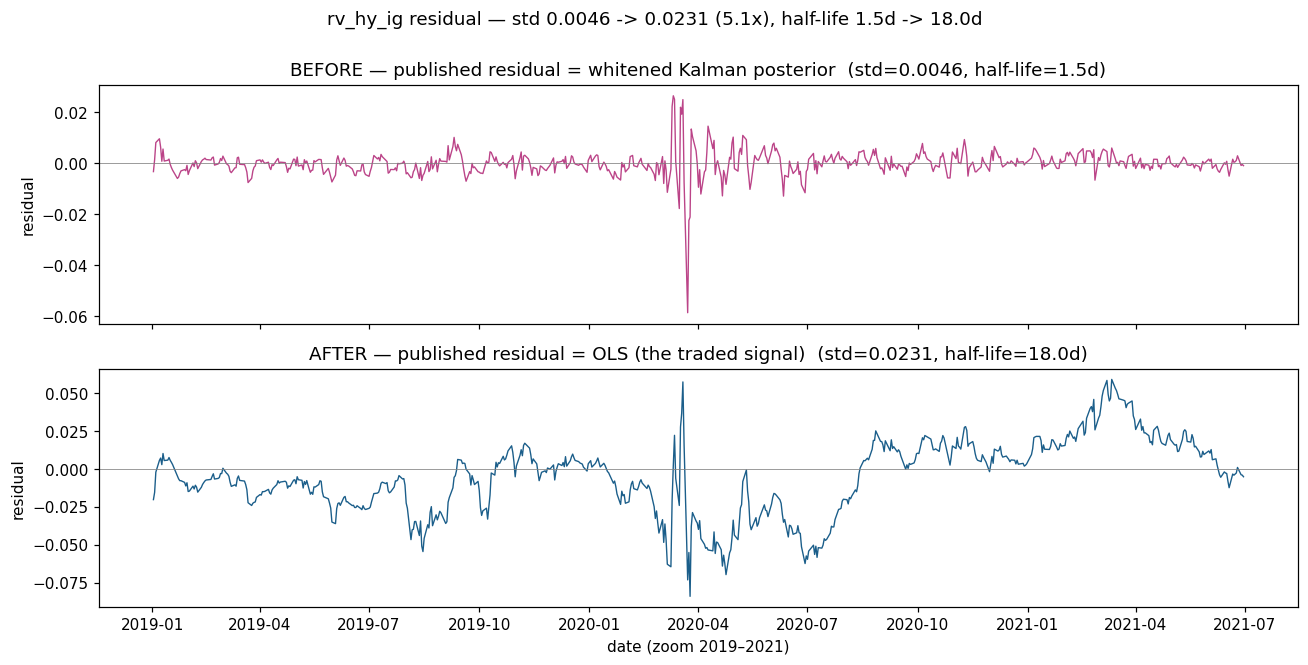

std jump 0.0046 -> 0.0231  (5.1x);  half-life 1.50d -> 18.0d


In [2]:
from signals.halflife import ou_halflife
b = before['rv_hy_ig_residual']; a = after['rv_hy_ig_residual']
sb, sa = b.iloc[252:].std(), a.iloc[252:].std()
hb, ha = ou_halflife(b.iloc[252:]), ou_halflife(a.iloc[252:])

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
win = slice('2019-01-01', '2021-06-30')
ax[0].plot(b.loc[win], color='#bb4488', lw=0.9)
ax[0].set_title(f'BEFORE — published residual = whitened Kalman posterior  (std={sb:.4f}, half-life={hb:.1f}d)')
ax[1].plot(a.loc[win], color='#1b5e8a', lw=0.9)
ax[1].set_title(f'AFTER — published residual = OLS (the traded signal)  (std={sa:.4f}, half-life={ha:.1f}d)')
for x in ax: x.axhline(0, color='grey', lw=0.5); x.set_ylabel('residual')
ax[1].set_xlabel('date (zoom 2019–2021)')
fig.suptitle(f'rv_hy_ig residual — std {sb:.4f} -> {sa:.4f} ({sa/sb:.1f}x), half-life {hb:.1f}d -> {ha:.1f}d', y=1.00)
fig.tight_layout(); fig.savefig(PLOTS/'residual_before_after.png', dpi=110); plt.show()
print(f'std jump {sb:.4f} -> {sa:.4f}  ({sa/sb:.1f}x);  half-life {hb:.2f}d -> {ha:.1f}d')

## 2 · The selector — ADF picks the wrong residual; the half-life band fixes it

The old selector chose the method with the **lowest ADF p-value**. But ADF
rewards whitening — the Kalman residual has the *most* extreme p (~1e-21)
precisely because it's noise. The v5.5 selector qualifies a method only if
it is stationary **and** has a tradeable OU half-life ∈ [5, 63] days. Now
Kalman is rejected (whitened) and DV01 rejected (too slow / non-stationary);
**OLS is selected** — the method the backtest already used.


rv_hy_ig — canonical (tradeability) selection: ols


,adf_p,half_life,hedge_cv,qualified,ADF_would_pick
ols,0.0,18.043159,0.152102,True,False
kalman,0.0,1.476396,0.005483,False,True
dv01,0.68788,454.523544,0.006685,False,False


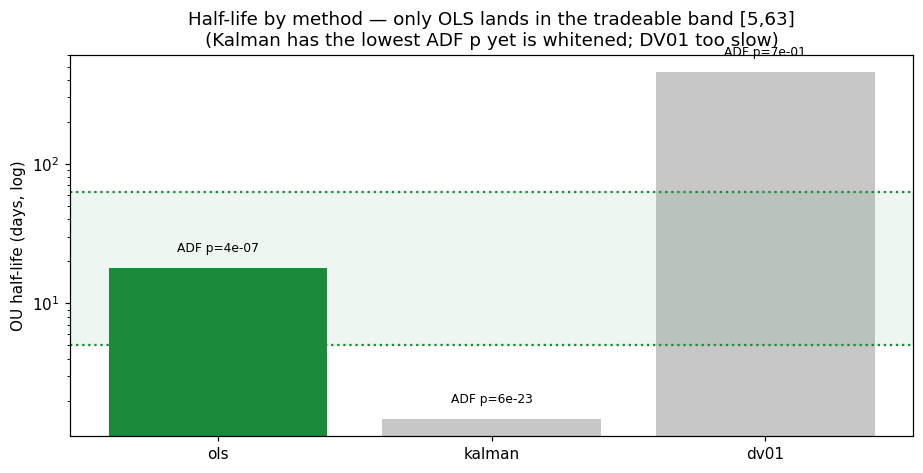

In [3]:
from signals.rv_signals import build_all_residuals, select_tradeable_method
res = build_all_residuals(after, credit, pycredit)
sel = select_tradeable_method(res)
chosen, diag = sel['rv_hy_ig']
tab = pd.DataFrame(diag).T[['adf_p','half_life','hedge_cv','qualified']]
tab['ADF_would_pick'] = (tab['adf_p'] == tab['adf_p'].min())
print('rv_hy_ig — canonical (tradeability) selection:', chosen)
display(tab)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
methods = list(diag); hl = [diag[m]['half_life'] for m in methods]
colors = ['#1b8a3a' if m==chosen else '#c7c7c7' for m in methods]
ax.bar(methods, hl, color=colors)
ax.axhspan(5, 63, color='#1b8a3a', alpha=0.07); ax.axhline(5, ls=':', color='#1b8a3a'); ax.axhline(63, ls=':', color='#1b8a3a')
ax.set_yscale('log'); ax.set_ylabel('OU half-life (days, log)')
for i,m in enumerate(methods):
    ax.annotate(f"ADF p={diag[m]['adf_p']:.0e}", (i, hl[i]*1.3), ha='center', fontsize=8)
ax.set_title('Half-life by method — only OLS lands in the tradeable band [5,63]\n(Kalman has the lowest ADF p yet is whitened; DV01 too slow)')
fig.tight_layout(); fig.savefig(PLOTS/'selector_band.png', dpi=110); plt.show()

## 3 · The dashboard signal — what the Today View was actually showing

The dashboard reads `z_rv_*` straight from `features.parquet`, so it
inherited the whitened residual: its z-scores and the HIGH-conviction tiers
(`equity_first` AND |z|>2) were computed on noise. After the repair they
reflect the OLS signal. Below: the HIGH-conviction signal-day count, before
vs after, against the v4 sanity baseline (178).


HIGH-conviction signal-days  BEFORE (whitened): 45   AFTER (OLS): 91   (v4 baseline 178)


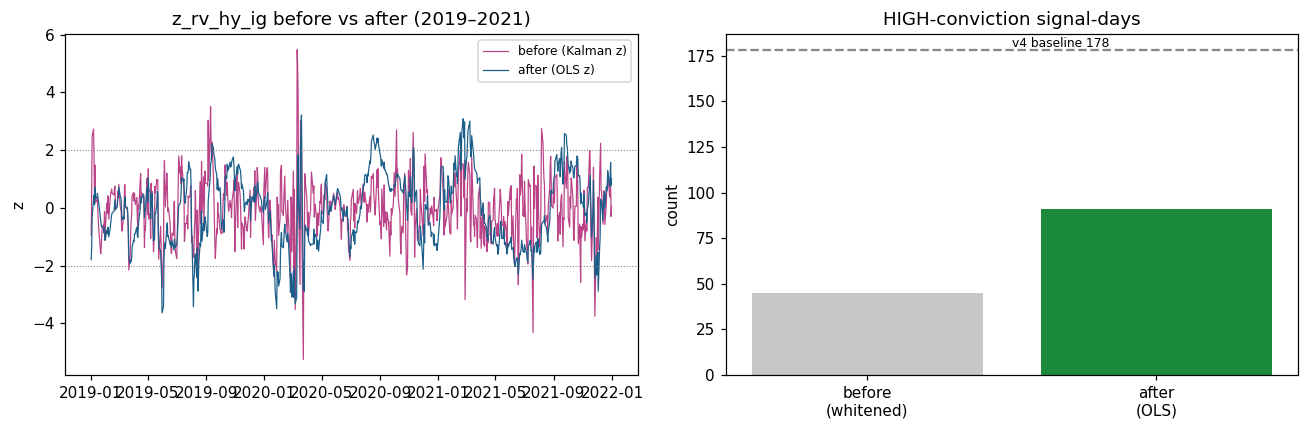

In [4]:
def high_count(df):
        ef = df['equity_credit_lag'].astype(str) == 'equity_first'
        n = 0
        for zc in ['z_rv_hy_ig','z_rv_credit_rates','z_rv_xterm']:
            n += int(((df[zc].abs() > 2.0) & ef).sum())
        return n
hb_, ha_ = high_count(before), high_count(after)
print(f'HIGH-conviction signal-days  BEFORE (whitened): {hb_}   AFTER (OLS): {ha_}   (v4 baseline 178)')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(before['z_rv_hy_ig'].loc['2019':'2021'], color='#bb4488', lw=0.8, label='before (Kalman z)')
ax[0].plot(after['z_rv_hy_ig'].loc['2019':'2021'], color='#1b5e8a', lw=0.8, label='after (OLS z)')
for thr in (2,-2): ax[0].axhline(thr, ls=':', color='grey', lw=0.7)
ax[0].set_title('z_rv_hy_ig before vs after (2019–2021)'); ax[0].legend(fontsize=8); ax[0].set_ylabel('z')
ax[1].bar(['before\n(whitened)','after\n(OLS)'], [hb_, ha_], color=['#c7c7c7','#1b8a3a'])
ax[1].axhline(178, ls='--', color='#888'); ax[1].annotate('v4 baseline 178', (0.5,178), fontsize=8, va='bottom')
ax[1].set_title('HIGH-conviction signal-days'); ax[1].set_ylabel('count')
fig.tight_layout(); fig.savefig(PLOTS/'dashboard_signal_before_after.png', dpi=110); plt.show()

## 4 · Strategy A — bit-identical pre/post repair

Strategy A always traded the OLS residual, which the repair never touched.
So its equity curve, Sharpe, hit rate and trade count are **unchanged** —
the cleanup removed dishonesty around the strategy, not the strategy. That
the validated result survived honest reconstruction is the strongest
evidence the 0.59 was never a whitening artifact.


Strategy A — net Sharpe 0.591 (v5 0.59) | hit 0.809 | trades 94 | maxDD $-152,025
A/B incremental Sharpe (thesis, rejected): -0.411  CI [-0.815,-0.009]


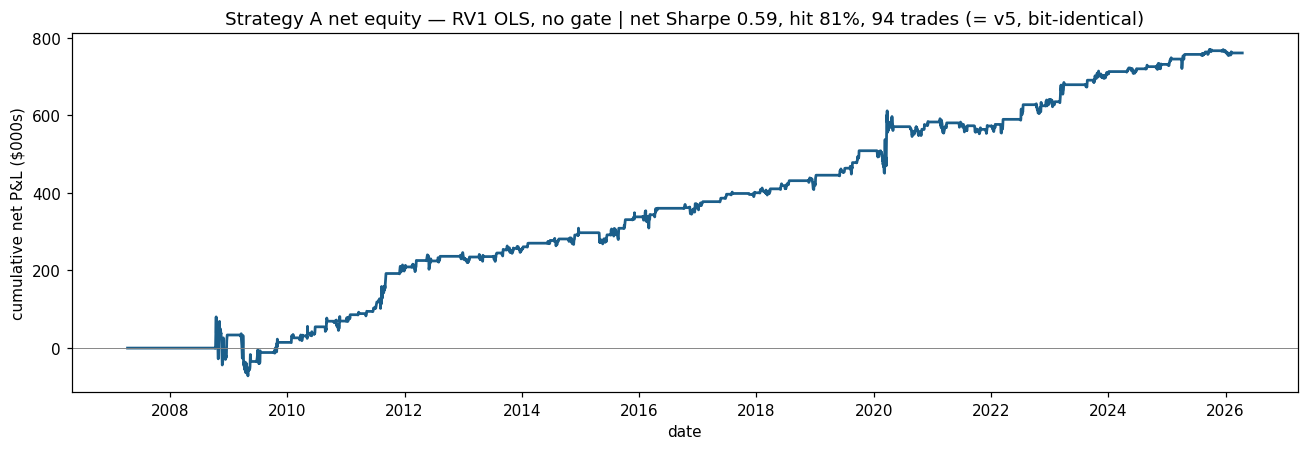

In [5]:
from backtest.ab_test import compare
ab = compare(after, res)   # method=None -> canonical (ols)
s = ab.summary_a
print(f'Strategy A — net Sharpe {s.sharpe:.3f} (v5 0.59) | hit {s.hit_rate:.3f} | trades {s.n_trades} | maxDD ${s.max_drawdown:,.0f}')
print(f'A/B incremental Sharpe (thesis, rejected): {ab.bootstrap["delta_sharpe"]:+.3f}  CI [{ab.bootstrap["ci_lo"]:.3f},{ab.bootstrap["ci_hi"]:.3f}]')

eq = ab.strategy_a.daily_pnl.cumsum()/1e3
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(eq.index, eq.values, color='#1b5e8a', lw=1.8)
ax.axhline(0, color='grey', lw=0.6)
ax.set_title(f'Strategy A net equity — RV1 OLS, no gate | net Sharpe {s.sharpe:.2f}, hit {s.hit_rate:.0%}, {s.n_trades} trades (= v5, bit-identical)')
ax.set_ylabel('cumulative net P&L ($000s)'); ax.set_xlabel('date')
fig.tight_layout(); fig.savefig(PLOTS/'strategy_a_equity.png', dpi=110); plt.show()

## Summary

| | before (v5.5 audit) | after (repair) |
|---|---|---|
| published `rv_hy_ig` residual | whitened Kalman (std 0.005, ~1.5d half-life) | OLS (std 0.023, 18d half-life) |
| selector | lowest ADF p → picks whitened | stationary **and** half-life ∈ [5,63] → picks OLS |
| dashboard / backtest residual | **different series** | **bit-identical (E1)** |
| `rv_xterm` DV01 | copy-paste of pair-1 ratio | removed (E4) |
| C22 framing | "43–67% across methods" (2 legs degenerate) | **67%, OLS only** |
| Strategy A | Sharpe 0.59 | **Sharpe 0.591 — unchanged** |

The winning strategy didn't move. What moved was everything you *show,
select, and defend* — which is exactly what had to be honest before Tier 2
makes the dashboard a live, daily-refreshed paper-trading cockpit.
